## Statistically Significant Findings (p < 0.05)

### **Across ADT agents**

* **History of CAD (hx_cad)** *(p = 0.0113)*

  * Clear imbalance across groups.
  * **Orgovyx** patients have notably **lower CAD prevalence** (6/79 ≈ 7.6%) compared to:

    * Bicalutamide (8/27 ≈ 29.6%)
    * Firmagon (4/18 ≈ 22.2%)
    * Lupron (14/53 ≈ 26.4%)
  * → Suggests possible **treatment selection bias** (healthier cardiac patients on Orgovyx).

* **Exercise counseling** *(p = 0.0362)*

  * Very uneven distribution:

    * Bicalutamide: **0 patients received counseling**
    * Firmagon / Lupron / Orgovyx: small but present counts
  * → Likely reflects **practice pattern differences**, not biology.

* **Echocardiogram ordered (echo_ordered)** *(p = 0.0160)*

  * Orgovyx has **lowest echo utilization**
  * Bicalutamide relatively higher proportion
  * → Could reflect **baseline cardiac risk differences or provider behavior**

---

### **Across NHT therapies**

* **Age** *(p = 0.0004)*

  * Strong difference across groups:

    * Younger: **Abiraterone (~68.7)**
    * Older: **Darolutamide (~74.2), Enzalutamide (~73.3)**
  * → Clinically meaningful; suggests **age-based treatment selection**

* **History of arrhythmia (hx_arrhythmia)** *(p = 0.0498)*

  * Higher proportion in:

    * Enzalutamide (6/19 ≈ 31.6%)
  * Lower in:

    * Darolutamide (7/82 ≈ 8.5%)
  * → Potential **cardiac comorbidity influencing therapy choice**

---

##  Borderline / Near-Significant Trends (0.05–0.10)

### **Baseline (Risk vs Not At Risk)**

* **Hypertension (hx_htn)** *(p = 0.0561)*

  * Higher in “At Risk” group (67.9% vs 53.3%)
  * → Suggestive but not statistically significant

* **Smoking history (hx_smoking)** *(p = 0.0720)*

  * More smokers in “At Risk” group
  * → Consistent with expected cardiovascular risk patterns

---

## Notable (Non-Significant but Interesting) Patterns

### **Baseline table**

* Age and BMI are **very similar** across risk groups
  → Suggests risk classification is driven more by **comorbidities than demographics**

* Ethnicity distribution shows variation but **no statistical difference**
  → Likely underpowered for subgroup differences

---

### **ADT comparisons**

* Most comorbidities (**HTN, HLD, DM2, CHF, PAD, CVA**) are **well balanced**
  → Good comparability across treatment groups

* **Orgovyx stands out**:

  * Lower CAD prevalence
  * Lower echo ordering
    → Reinforces possible **selection of lower-risk patients**

---

### **NHT comparisons**

* Aside from age:

  * Most clinical variables are **well balanced**
  * Suggests relatively **consistent prescribing patterns**

* **Darolutamide group appears older but with fewer arrhythmias**
  → Could reflect perceived **better cardiac safety profile**

---

## Overall

* **Evidence of treatment selection bias**:

  * ADT: cardiac history (CAD) influences agent choice
  * NHT: age and arrhythmia influence therapy selection

* **Clinical decision-making signals**:

  * Younger → Abiraterone
  * Older → Darolutamide / Enzalutamide
  * Lower cardiac risk → Orgovyx

* **Most baseline variables are balanced**, which is good for downstream analysis—but:

  * The **few significant imbalances are clinically meaningful**, especially cardiac-related ones.


In [32]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [33]:
BASE_FILE = os.path.join("..", "..", "data", "processed",
                          "cardio_onc_prostate_06_broad_clean.csv")
OUT_DIR = os.path.join("..", "results", "01")
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(BASE_FILE)
print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (239, 60)
   unique_patient_id  ethnicity nht_auth_date nht_start_date    bmi  \
0                1.0        NaN    2022-01-09            NaN    NaN   
1                2.0        NaN    2022-01-11            NaN    NaN   
2                3.0  Caucasian    2022-01-12     2022-02-01  25.99   
3                4.0      Asian    2022-01-14     2022-02-14  22.55   
4                5.0        NaN    2022-01-19            NaN    NaN   

  specific_nht_used   age adt_start_date     adt_agent  hx_smoking  ...  \
0               NaN   NaN            NaN           NaN         NaN  ...   
1               NaN   NaN            NaN           NaN         NaN  ...   
2      Darolutamide  73.0     2018-01-26        Lupron         1.0  ...   
3       Apalutamide  93.0     2021-12-01  Bicalutamide         0.0  ...   
4       Abiraterone   NaN            NaN           NaN         NaN  ...   

   bp_meds_post_binary  lipid_meds_post_binary  dm_meds_post_binary  at_risk  \
0                

In [34]:
# Primary outcome
target = "at_risk"

# Demographics
demographics = ["age", "ethnicity", "bmi"]

risk_factors = [
    "hx_htn",        # Hypertension
    "hx_hld",        # Hyperlipidemia
    "hx_dm2",        # Type 2 Diabetes
    "hx_smoking",    # Smoking history
    "hx_cad",        # Coronary artery disease
    "hx_chf",        # Congestive heart failure
    "hx_arrhythmia", # Arrhythmia
    "hx_pad",        # Peripheral artery disease
    "hx_cva"         # Cerebrovascular accident (stroke)
]

care_patterns = [
    "has_pcp",           # Has primary care provider
    "cards_prior",       # Prior cardiology care
    "diet_counseling",   # Diet counseling received
    "exercise_counseling", # Exercise counseling received
    "echo_ordered",      # Echocardiogram ordered
    "ecg_done"           # ECG performed
]

categorical_vars = [
    "ethnicity", "hx_htn", "hx_hld", "hx_dm2", "hx_smoking",
    "hx_cad", "hx_chf", "hx_arrhythmia", "hx_pad", "hx_cva",
    "has_pcp", "cards_prior", "diet_counseling", "exercise_counseling",
    "echo_ordered", "ecg_done"
]

In [35]:
def summarize_continuous(df, col, target):
    """
    Compare continuous variable between two groups (at-risk vs not at-risk).

    Uses t-test if data appears normal, otherwise Mann-Whitney U test.

    Returns:
        dict: Summary statistics and p-value
    """
    group0 = df[df[target] == 0][col].dropna()
    group1 = df[df[target] == 1][col].dropna()

    # Summary stats
    summary = {
        "Overall": f"{df[col].mean():.2f} ± {df[col].std():.2f}",
        "Not At Risk": f"{group0.mean():.2f} ± {group0.std():.2f}",
        "At Risk": f"{group1.mean():.2f} ± {group1.std():.2f}",
    }

    # Normality check
    if len(group0) > 20 and len(group1) > 20:
        sample_size = min(500, len(df[col].dropna()))
        p_norm = stats.shapiro(df[col].dropna().sample(sample_size))[1]
    else:
        p_norm = 0

    # Choose appropriate test
    if p_norm > 0.05:
        stat, p = stats.ttest_ind(group0, group1, equal_var=False)
        test = "t-test"
    else:
        stat, p = stats.mannwhitneyu(group0, group1, alternative="two-sided")
        test = "Mann-Whitney"

    summary["p-value"] = f"{p:.4f}"
    summary["Test"] = test

    return summary


def summarize_categorical(df, col, target):
    """
    Compare categorical variable between two groups using chi-square test.

    Returns:
        list: Rows for each category with counts, percentages, and p-value
    """
    ct = pd.crosstab(df[col], df[target])
    pct = ct.div(ct.sum(axis=0), axis=1) * 100

    # Chi-square test
    try:
        chi2, p, _, _ = stats.chi2_contingency(ct)
    except:
        p = np.nan

    rows = []
    for category in ct.index:
        row = {
            "Variable": f"{col} = {category}",
            "Overall": f"{ct.loc[category].sum()}",
            "Not At Risk": f"{ct.loc[category, 0]} ({pct.loc[category, 0]:.1f}%)" if 0 in ct.columns else "0",
            "At Risk": f"{ct.loc[category, 1]} ({pct.loc[category, 1]:.1f}%)" if 1 in ct.columns else "0",
            "p-value": f"{p:.4f}"
        }
        rows.append(row)

    return rows


def summarize_continuous_by_group(df, col, group_var):
    """
    Compare continuous variable across multiple groups.

    Uses ANOVA if normal, otherwise Kruskal-Wallis test.
    """
    groups = [g[col].dropna() for _, g in df.groupby(group_var)]
    summary = df.groupby(group_var)[col].agg(["mean", "std", "median", "count"])

    # Normality check
    sample_size = min(500, len(df[col].dropna()))
    p_norm = stats.shapiro(df[col].dropna().sample(sample_size))[1]

    # Choose test
    if p_norm > 0.05:
        stat, p = stats.f_oneway(*groups)
        test = "ANOVA"
    else:
        stat, p = stats.kruskal(*groups)
        test = "Kruskal-Wallis"

    return summary, p, test


def summarize_categorical_by_group(df, col, group_var):
    """
    Compare categorical variable across multiple groups using chi-square.
    """
    ct = pd.crosstab(df[col], df[group_var])

    try:
        chi2, p, _, _ = stats.chi2_contingency(ct)
    except:
        p = np.nan

    return ct, p


In [36]:
print("\nGENERATING TABLE 1: Baseline Characteristics by Risk Status\n")

table1_rows = []

# Continuous variables (age, BMI)
for col in ["age", "bmi"]:
    summary = summarize_continuous(df, col, target)
    row = {
        "Variable": col,
        "Overall": summary["Overall"],
        "Not At Risk": summary["Not At Risk"],
        "At Risk": summary["At Risk"],
        "p-value": summary["p-value"]
    }
    table1_rows.append(row)

# Categorical variables
for col in categorical_vars:
    rows = summarize_categorical(df, col, target)
    table1_rows.extend(rows)

# Create and save Table 1
table1 = pd.DataFrame(table1_rows)
table1["p-value"] = table1["p-value"].replace("nan", "")
table1.fillna("", inplace=True)

OUT_FILE = os.path.join(OUT_DIR, "table1_baseline.csv")
table1.to_csv(OUT_FILE, index=False)
print(f"Saved Table 1 to: {OUT_FILE}")
print(table1.head(20))


GENERATING TABLE 1: Baseline Characteristics by Risk Status

Saved Table 1 to: ../results/01/table1_baseline.csv
                 Variable       Overall   Not At Risk       At Risk p-value
0                     age  71.60 ± 8.91  71.77 ± 9.38  71.41 ± 8.46  0.7733
1                     bmi  27.66 ± 5.13  27.80 ± 5.22  27.52 ± 5.11  0.8451
2       ethnicity = Asian            27    15 (12.5%)    12 (15.2%)  0.3554
3       ethnicity = Black            17      8 (6.7%)     9 (11.4%)  0.3554
4   ethnicity = Caucasian           110    71 (59.2%)    39 (49.4%)  0.3554
5    ethnicity = Hispanic            22    15 (12.5%)      7 (8.9%)  0.3554
6       ethnicity = Other            23     11 (9.2%)    12 (15.2%)  0.3554
7            hx_htn = 0.0            82    57 (46.7%)    25 (32.1%)  0.0561
8            hx_htn = 1.0           118    65 (53.3%)    53 (67.9%)  0.0561
9            hx_hld = 0.0            96    59 (47.6%)    37 (46.8%)  1.0000
10           hx_hld = 1.0           107    65 (52.

In [37]:

print("\nANALYZING BASELINE DIFFERENCES ACROSS ADT AGENTS\n")

group_var = "adt_agent"

# Filter to groups with sufficient sample size
min_n = 5
counts = df[group_var].value_counts()
valid_groups = counts[counts >= min_n].index
df_adt = df[df[group_var].isin(valid_groups)].copy()

print("ADT agent distribution:")
print(df_adt[group_var].value_counts())

adt_results = []

# Continuous variables
for col in ["age", "bmi"]:
    summary, p, test = summarize_continuous_by_group(df_adt, col, group_var)
    adt_results.append({
        "Variable": col,
        "Test": test,
        "p-value": p
    })
    print(f"\n{col} ({test}) p={p:.4f}")
    print(summary)

# Categorical variables
for col in categorical_vars:
    ct, p = summarize_categorical_by_group(df_adt, col, group_var)
    adt_results.append({
        "Variable": col,
        "Test": "Chi-square",
        "p-value": p
    })
    print(f"\n{col} (Chi-square) p={p:.4f}")
    print(ct)

# Save ADT comparison results
adt_table = pd.DataFrame(adt_results)
OUT_FILE = os.path.join(OUT_DIR, "adt_group_comparisons.csv")
adt_table.to_csv(OUT_FILE, index=False)
print(f"\n✓ Saved ADT comparison results to: {OUT_FILE}")


ANALYZING BASELINE DIFFERENCES ACROSS ADT AGENTS

ADT agent distribution:
adt_agent
Orgovyx         80
Lupron          55
Bicalutamide    27
Firmagon        18
Name: count, dtype: int64

age (ANOVA) p=0.1823
                   mean       std  median  count
adt_agent                                       
Bicalutamide  72.222222  8.464102    73.0     27
Firmagon      70.444444  8.853196    69.5     18
Lupron        73.109091  9.132102    74.0     55
Orgovyx       69.797468  9.009083    70.0     79

bmi (Kruskal-Wallis) p=0.8961
                   mean       std  median  count
adt_agent                                       
Bicalutamide  28.718889  7.945258   27.25     27
Firmagon      27.120000  4.014953   26.90     18
Lupron        27.834815  5.233023   27.90     54
Orgovyx       27.710506  4.526987   28.07     79

ethnicity (Chi-square) p=0.6597
adt_agent  Bicalutamide  Firmagon  Lupron  Orgovyx
ethnicity                                         
Asian                 5         4    

In [38]:
print("\nANALYZING BASELINE DIFFERENCES ACROSS NHT THERAPIES\n")

group_var = "specific_nht_used"

# Continuous variables
for col in ["age", "bmi"]:
    groups = [g[col].dropna() for _, g in df.groupby(group_var)]

    sample_size = min(500, len(df[col].dropna()))
    p_norm = stats.shapiro(df[col].dropna().sample(sample_size))[1]

    if p_norm > 0.05:
        stat, p = stats.f_oneway(*groups)
        test = "ANOVA"
    else:
        stat, p = stats.kruskal(*groups)
        test = "Kruskal-Wallis"

    print(f"\n{col} ({test}) p={p:.4f}")
    print(df.groupby(group_var)[col].agg(["mean", "std", "median", "count"]))

# Categorical variables
for col in categorical_vars:
    ct = pd.crosstab(df[col], df[group_var])

    try:
        chi2, p, _, _ = stats.chi2_contingency(ct)
    except:
        p = np.nan

    print(f"\n{col} (Chi-square) p={p:.4f}")
    print(ct)


ANALYZING BASELINE DIFFERENCES ACROSS NHT THERAPIES


age (ANOVA) p=0.0004
                        mean       std  median  count
specific_nht_used                                    
Abiraterone        68.685393  9.024708    69.0     89
Apalutamide        72.071429  8.713070    73.5     14
Darolutamide       74.204819  8.412765    75.0     83
Enzalutamide       73.333333  7.164728    71.0     21

bmi (Kruskal-Wallis) p=0.3917
                        mean       std  median  count
specific_nht_used                                    
Abiraterone        28.305333  5.882066  28.180     90
Apalutamide        27.222857  4.710082  26.565     14
Darolutamide       26.866024  4.462692  26.520     83
Enzalutamide       28.398000  4.123491  28.195     20

ethnicity (Chi-square) p=0.3540
specific_nht_used  Abiraterone  Apalutamide  Darolutamide  Enzalutamide
ethnicity                                                              
Asian                       14            3             9           

✓ Saved: features_by_risk.png


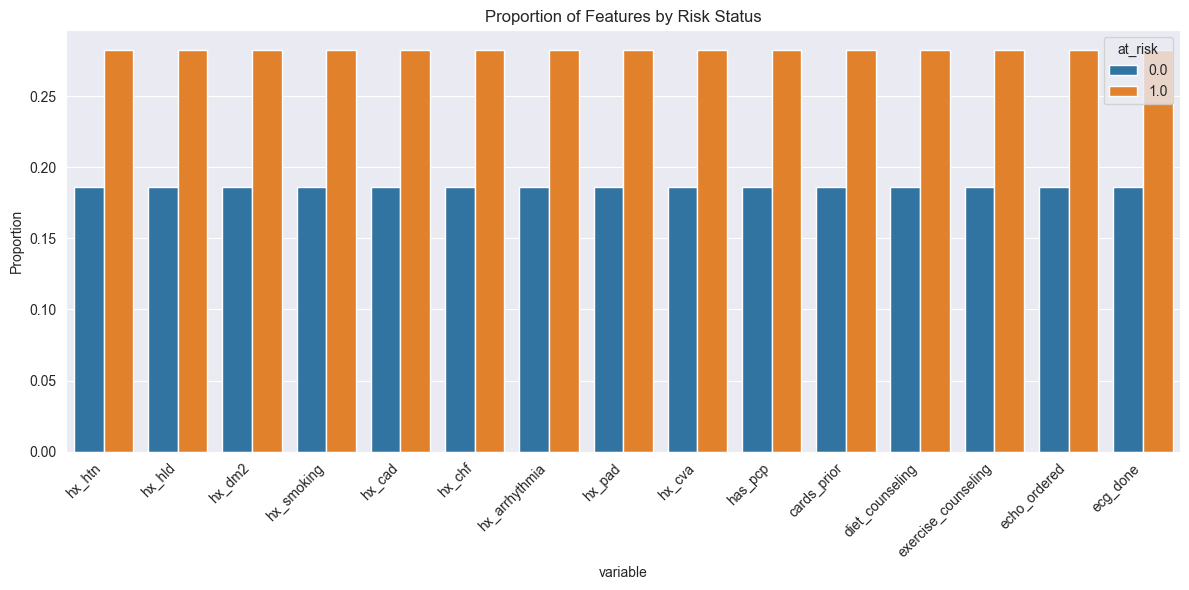

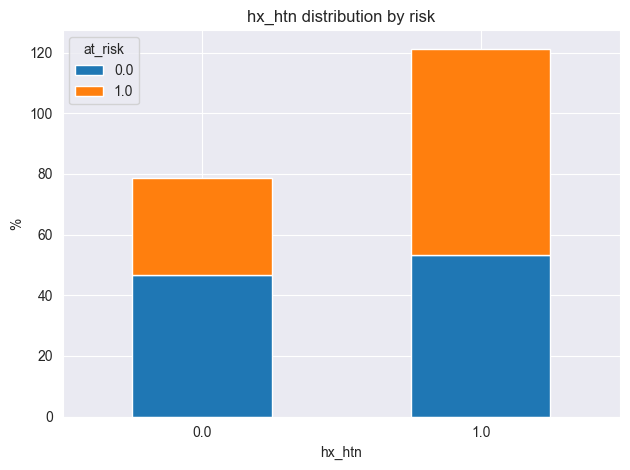

✓ Saved: stacked_hx_htn.png


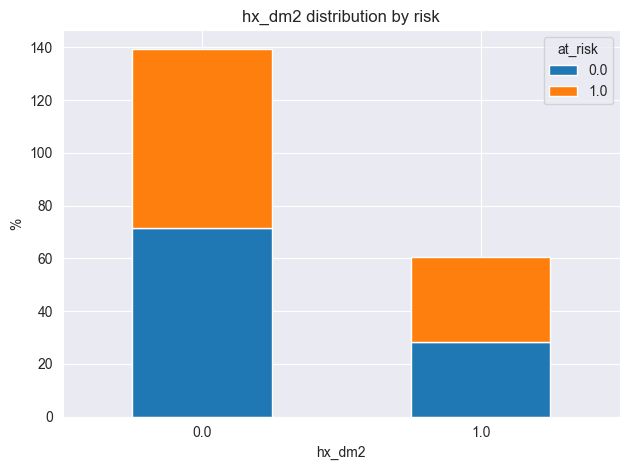

✓ Saved: stacked_hx_dm2.png


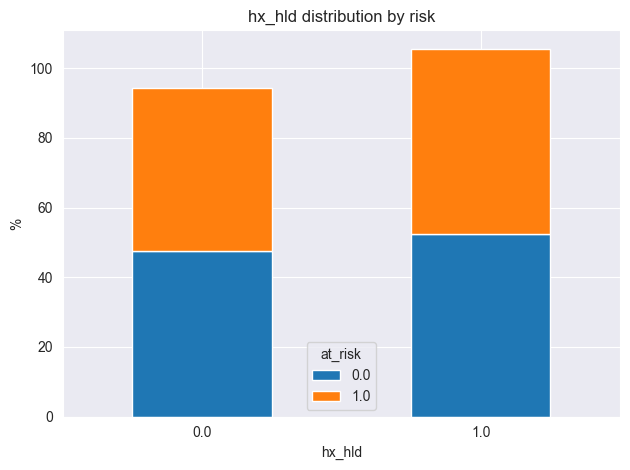

✓ Saved: stacked_hx_hld.png


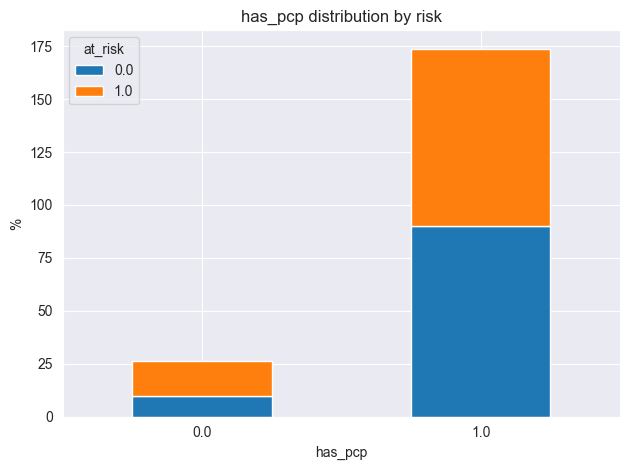

✓ Saved: stacked_has_pcp.png
✓ Saved: age_by_adt.png


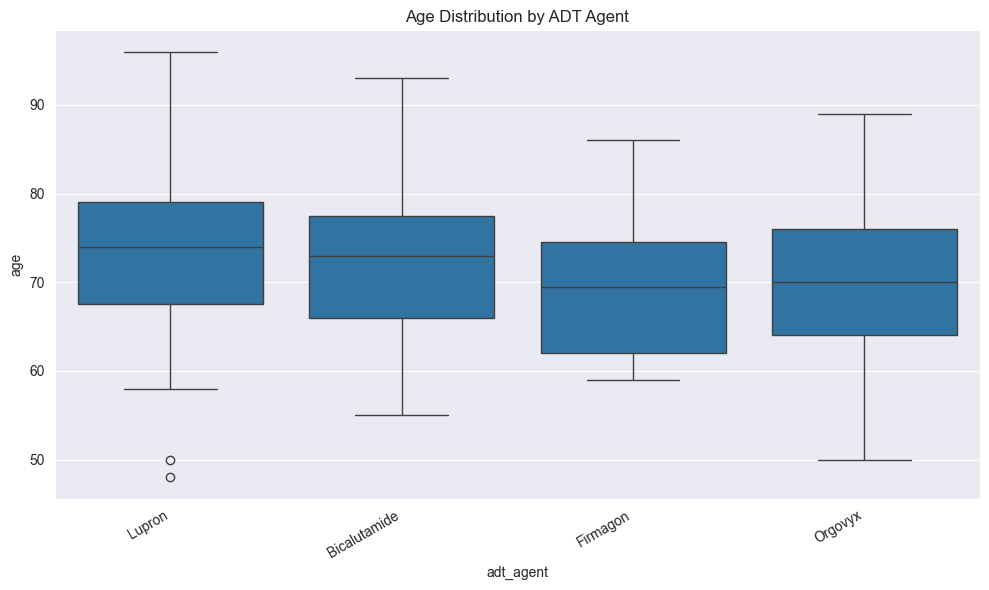

✓ Saved: adt_hx_htn.png


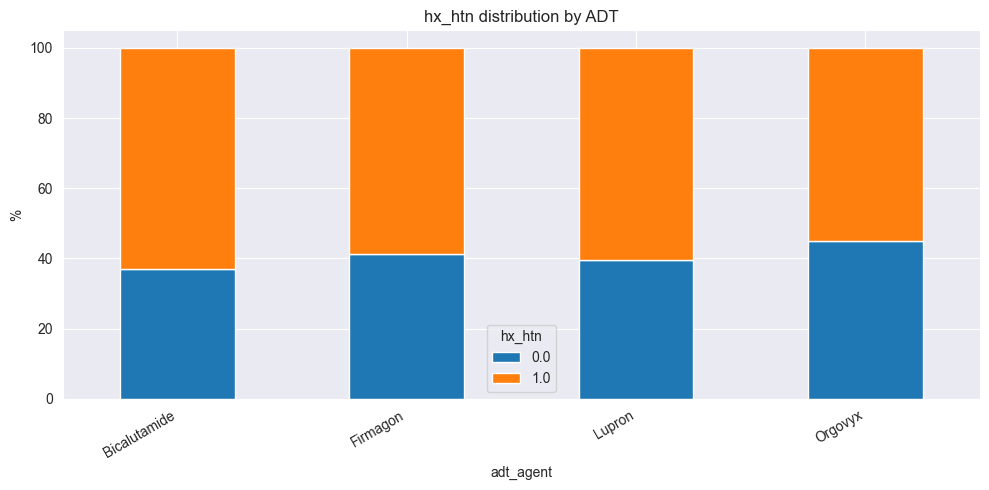

✓ Saved: adt_hx_dm2.png


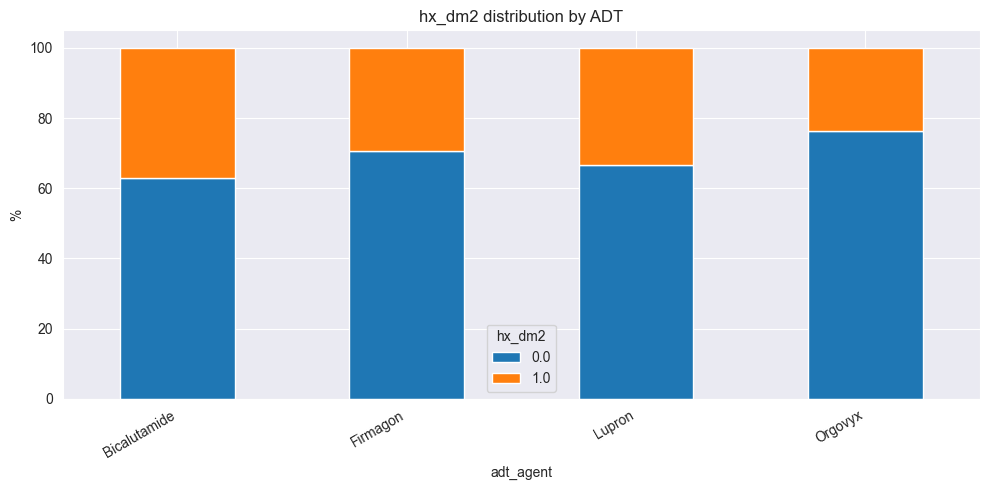

✓ Saved: adt_hx_hld.png


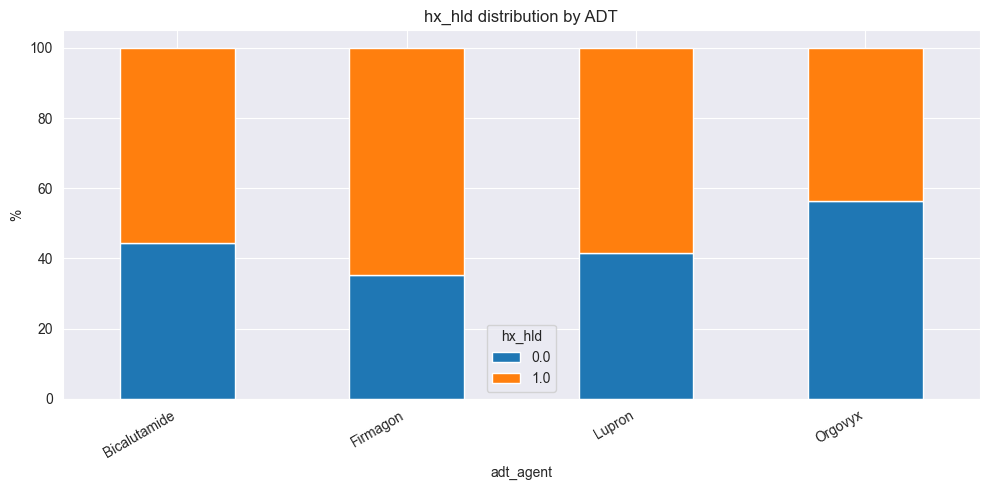

✓ Saved: adt_has_pcp.png


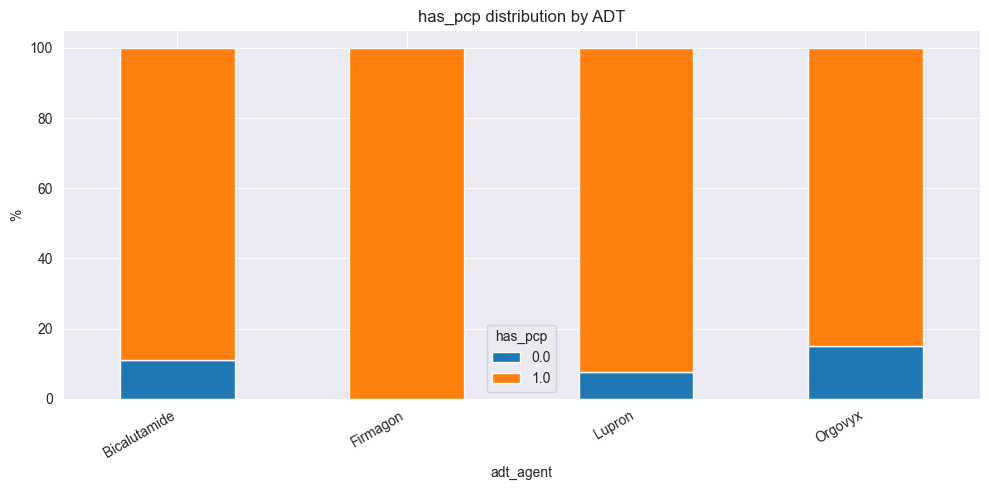


ANALYSIS COMPLETE


In [39]:
# 1. Binary features by risk status
binary_cols = risk_factors + [
    "has_pcp", "cards_prior", "diet_counseling",
    "exercise_counseling", "echo_ordered", "ecg_done"
]

plot_df = []
for col in binary_cols:
    temp = df.groupby(target)[col].mean().reset_index()
    temp["variable"] = col
    plot_df.append(temp)

plot_df = pd.concat(plot_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="variable", y=col, hue=target)
plt.xticks(rotation=45, ha='right')
plt.title("Proportion of Features by Risk Status")
plt.ylabel("Proportion")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "features_by_risk.png"), dpi=300)
print("✓ Saved: features_by_risk.png")
plt.show()

# 2. Stacked bar charts for key variables
def stacked_plot(df, col, target):
    ct = pd.crosstab(df[col], df[target], normalize="columns") * 100
    ct.plot(kind="bar", stacked=True)
    plt.title(f"{col} distribution by risk")
    plt.ylabel("%")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"stacked_{col}.png"), dpi=300)
    plt.show()

for col in ["hx_htn", "hx_dm2", "hx_hld", "has_pcp"]:
    stacked_plot(df, col, target)
    print(f"✓ Saved: stacked_{col}.png")

# 3. Age by ADT agent
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_adt, x="adt_agent", y="age")
plt.xticks(rotation=30, ha='right')
plt.title("Age Distribution by ADT Agent")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "age_by_adt.png"), dpi=300)
print("✓ Saved: age_by_adt.png")
plt.show()

# 4. Comorbidities by ADT agent
for col in ["hx_htn", "hx_dm2", "hx_hld", "has_pcp"]:
    ct = pd.crosstab(df_adt[col], df_adt["adt_agent"], normalize="columns") * 100
    ct.T.plot(kind="bar", stacked=True, figsize=(10, 5))
    plt.title(f"{col} distribution by ADT")
    plt.ylabel("%")
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"adt_{col}.png"), dpi=300)
    print(f"✓ Saved: adt_{col}.png")
    plt.show()

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)